In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook display settings
plt.style.use('default')
sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

# Display first rows
df.head()

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A


In [2]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1407328, 6)

Columns:
Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')

Data Types:
Unnamed: 0    int64
headline        str
url             str
publisher       str
date            str
stock           str
dtype: object


In [3]:
# Missing values
missing_values = df.isnull().sum()

print(missing_values)

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64


In [4]:
df.describe(include='all')

,Unnamed: 0,headline,url,publisher,date,stock
count,1.407328e+06,1407328,1407328,1407328,1407328,1407328
unique,NaN,845770,883429,1034,39957,6204
top,NaN,Benzinga's Top Upgrades,https://www.benzinga.com/news/20/03/15538835/s...,Paul Quintaro,2020-03-12 00:00:00,MRK
freq,NaN,5449,1704,228373,1766,3333
mean,7.072454e+05,NaN,NaN,NaN,NaN,NaN
std,4.081009e+05,NaN,NaN,NaN,NaN,NaN
min,0.000000e+00,NaN,NaN,NaN,NaN,NaN
25%,3.538128e+05,NaN,NaN,NaN,NaN,NaN
50%,7.072395e+05,NaN,NaN,NaN,NaN,NaN
75%,1.060710e+06,NaN,NaN,NaN,NaN,NaN


In [5]:
# Create headline length column
df['headline_length'] = df['headline'].astype(str).apply(len)

# Statistics
df['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

In [6]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], utc=True)

# Verify conversion
print(df['date'].dtype)

ValueError: time data "2020-05-22 00:00:00" doesn't match format "%Y-%m-%d %H:%M:%S%z". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [7]:
# Convert mixed-format dates safely
df['date'] = pd.to_datetime(
    df['date'],
    format='mixed',
    utc=True
)

# Verify datatype
print(df['date'].dtype)

datetime64[us, UTC]


In [8]:
# Top publishers
top_publishers = df['publisher'].value_counts().head(15)

print(top_publishers)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313
Benzinga_Newsdesk     19410
Zacks                 19390
Jayson Derrick        19050
Name: count, dtype: int64


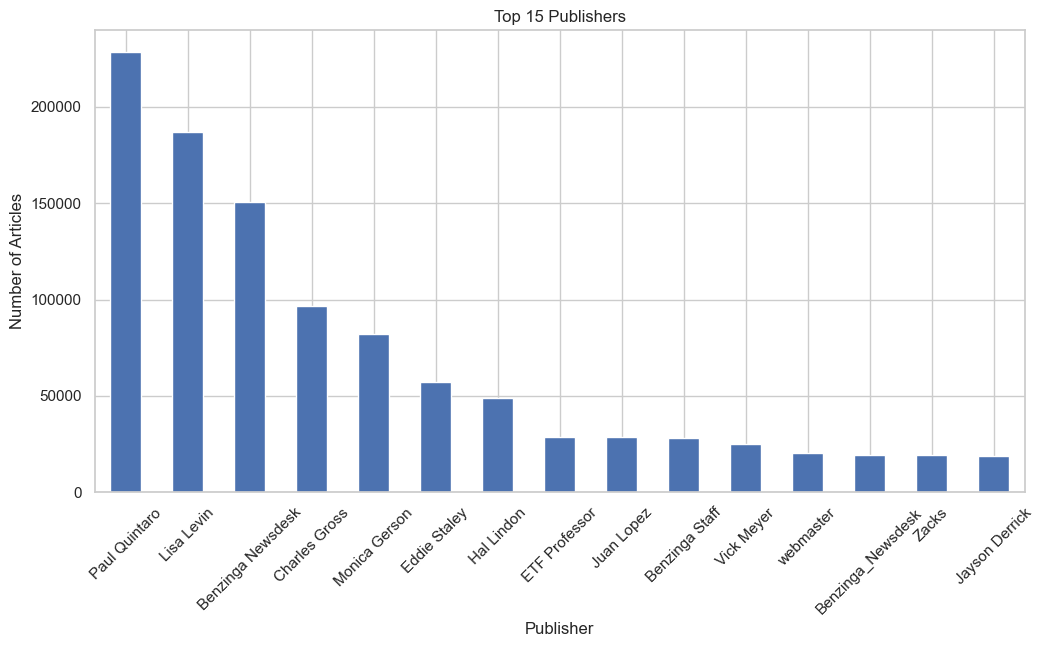

In [9]:
plt.figure(figsize=(12,6))

top_publishers.plot(kind='bar')

plt.title('Top 15 Publishers')
plt.xlabel('Publisher')
plt.ylabel('Number of Articles')

plt.xticks(rotation=45)

plt.show()

In [10]:
articles_per_day = df.groupby(df['date'].dt.date).size()

print(articles_per_day.head())

date
2009-02-14    1
2009-04-27    2
2009-04-29    1
2009-05-22    1
2009-05-27    6
dtype: int64


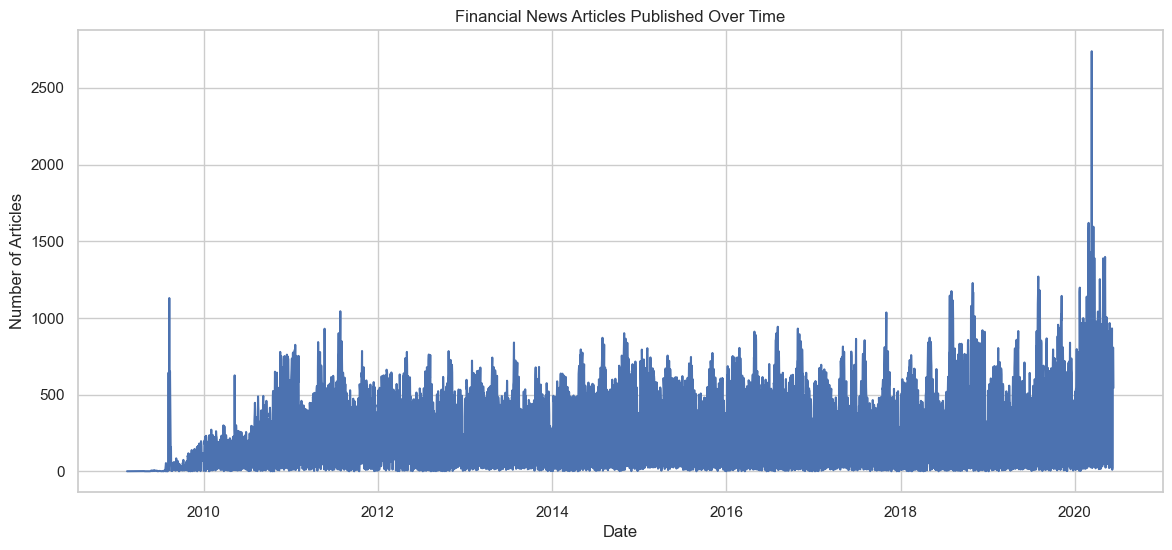

In [11]:
plt.figure(figsize=(14,6))

articles_per_day.plot()

plt.title('Financial News Articles Published Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Articles')

plt.show()

In [12]:
print(df['date'].dtype)

datetime64[us, UTC]


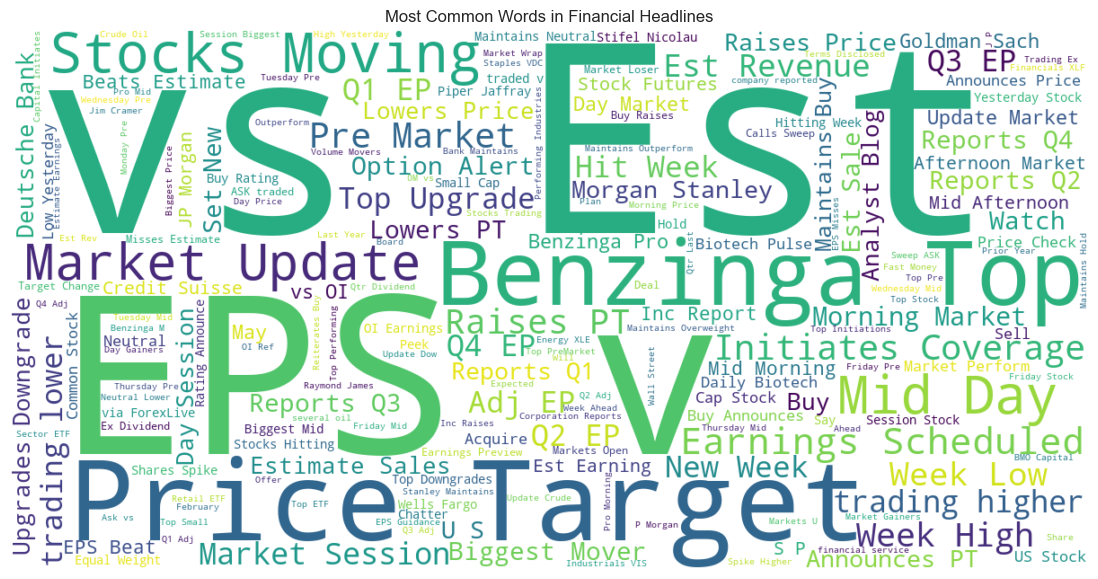

In [13]:
from wordcloud import WordCloud

# Combine all headlines into one text
text = " ".join(df['headline'].astype(str))

# Generate word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis'
).generate(text)

# Plot
plt.figure(figsize=(15,7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title('Most Common Words in Financial Headlines')

plt.show()

In [14]:
import re
import nltk

# Download stopwords
nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Text cleaning function
def clean_text(text):
    
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+', '', text)
    
    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

# Apply cleaning
df['clean_headline'] = df['headline'].astype(str).apply(clean_text)

# Preview
df[['headline', 'clean_headline']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ho\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


,headline,clean_headline
0,Stocks That Hit 52-Week Highs On Friday,stocks hit week highs friday
1,Stocks That Hit 52-Week Highs On Wednesday,stocks hit week highs wednesday
2,71 Biggest Movers From Friday,biggest movers friday
3,46 Stocks Moving In Friday's Mid-Day Session,stocks moving fridays midday session
4,B of A Securities Maintains Neutral on Agilent...,b securities maintains neutral agilent technol...


In [15]:
from collections import Counter

# Combine cleaned headlines
all_words = " ".join(df['clean_headline']).split()

# Count frequency
word_freq = Counter(all_words)

# Top 20 words
top_words = word_freq.most_common(20)

top_words

[('vs', 162147),
 ('stocks', 161868),
 ('q', 157878),
 ('est', 140606),
 ('eps', 128929),
 ('shares', 114209),
 ('reports', 108707),
 ('update', 91680),
 ('market', 90880),
 ('earnings', 87185),
 ('sales', 79526),
 ('top', 78678),
 ('pt', 73054),
 ('week', 67669),
 ('announces', 66529),
 ('price', 64232),
 ('buy', 64060),
 ('downgrades', 61942),
 ('trading', 61158),
 ('benzingas', 57985)]

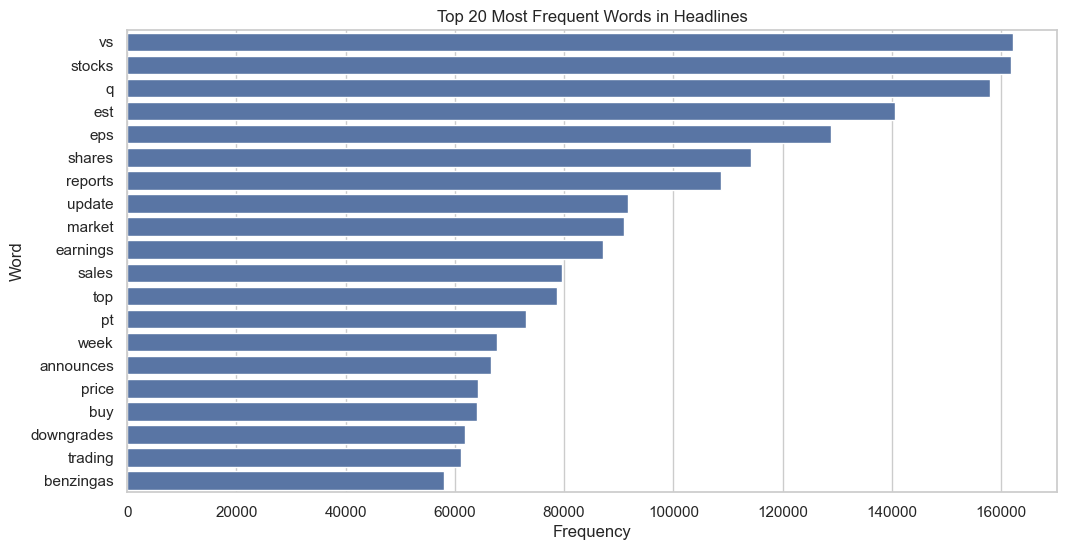

In [16]:
# Convert to DataFrame
top_words_df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_words_df,
    x='Frequency',
    y='Word'
)

plt.title('Top 20 Most Frequent Words in Headlines')

plt.show()